<a href="https://colab.research.google.com/github/CamiDRF/FinalProjectTalentoTech/blob/BranchFinalProjectTalentoTech/FinalProjectTalentTech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Proyecto Talento Tech

## Importacion de librerias


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install skimpy
from skimpy import skim
pd.options.display.float_format = '{:.3f}'.format
from sklearn.impute import SimpleImputer
!pip install --upgrade scikit-learn
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
!pip install fancyimpute
from fancyimpute import KNN
import plotly.express as px

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Base de Datos Emisiones de CO2 y PIB









**Cargar** **datos**


In [13]:
#Cargue de datos
dfOriginal = pd.read_excel("/content/drive/MyDrive/Talento Tech - Analisis de Datos/fuenteDatos/Project/dbClimateChange.xlsx")
dfOriginal.columns
dfOriginal.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13512 entries, 0 to 13511
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country code  13512 non-null  object
 1   Country name  13512 non-null  object
 2   Series code   13512 non-null  object
 3   Series name   13512 non-null  object
 4   SCALE         13512 non-null  object
 5   Decimals      13512 non-null  object
 6   1990          10017 non-null  object
 7   1991          10017 non-null  object
 8   1992          10017 non-null  object
 9   1993          10017 non-null  object
 10  1994          10017 non-null  object
 11  1995          10017 non-null  object
 12  1996          10017 non-null  object
 13  1997          10017 non-null  object
 14  1998          10017 non-null  object
 15  1999          10017 non-null  object
 16  2000          10017 non-null  object
 17  2001          10017 non-null  object
 18  2002          10017 non-null  object
 19  2003

In [14]:
#Pivote de dataframe original

df_melted = dfOriginal.melt( #melt "despivotea" un DataFrame, transformando las columnas en filas para facilitar el análisis y la visualización de datos.
    id_vars=['Country code', 'Country name', 'Series code', 'Series name', 'SCALE', 'Decimals'],
    var_name='Year',  # Nombre de la nueva columna para los años
    value_name='Value'  # Nombre de la nueva columna para los valores
)

# Ordenar el DataFrame (opcional)
df_melted = df_melted.sort_values(by=['Country code', 'Series code', 'Year'])

# Mostrar el resultado
#print(df_melted.head())
df_melted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297264 entries, 0 to 297263
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Country code  297264 non-null  object
 1   Country name  297264 non-null  object
 2   Series code   297264 non-null  object
 3   Series name   297264 non-null  object
 4   SCALE         297264 non-null  object
 5   Decimals      297264 non-null  object
 6   Year          297264 non-null  object
 7   Value         222739 non-null  object
dtypes: object(8)
memory usage: 20.4+ MB


In [15]:
#Se identifican los valores Unicos del los paises
pd.unique(df_melted['Country name'])

array(['Aruba', 'Andorra', 'Afghanistan', 'Angola', 'Albania',
       'United Arab Emirates', 'Argentina', 'Armenia', 'American Samoa',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas, The', 'Bosnia and Herzegovina',
       'Belarus', 'Belize', 'Bermuda', 'Bolivia', 'Brazil', 'Barbados',
       'Brunei Darussalam', 'Bhutan', 'Botswana',
       'Central African Republic', 'Canada', 'Switzerland',
       'Channel Islands', 'Chile', 'China', "Cote d'Ivoire", 'Cameroon',
       'Congo, Rep.', 'Cook Islands', 'Colombia', 'Comoros', 'Cape Verde',
       'Costa Rica', 'Cuba', 'Curacao', 'Cayman Islands', 'Cyprus',
       'Czech Republic', 'Germany', 'Djibouti', 'Dominica', 'Denmark',
       'Dominican Republic', 'Algeria', 'East Asia & Pacific',
       'Europe & Central Asia', 'Ecuador', 'Egypt, Arab Rep.',
       'Euro area', 'Eritrea', 'Spain', 'Estonia', 'Ethiopia'

In [16]:
#Se crea un data frame con las variables a analizar
df_variables = df_melted.loc[df_melted['Series code'].isin(['NY.GDP.MKTP.CD', 'EN.ATM.CO2E.PC', 'EN.ATM.CO2E.KT', 'EN.ATM.CO2E.PP.GD.KD'])]
pd.unique(df_variables['Series code'])


array(['EN.ATM.CO2E.KT', 'EN.ATM.CO2E.PC', 'EN.ATM.CO2E.PP.GD.KD',
       'NY.GDP.MKTP.CD'], dtype=object)

In [17]:
# Se crea un data frame con los paises a analizar
df_paises = df_variables.loc[df_variables['Country name'].isin(['China', 'United States', 'India', 'Russian Federation', 'Japan', 'Brazil', 'Mexico', 'Argentina', 'Colombia', 'Venezuela, RB'])]
pd.unique(df_paises['Country name'])

array(['Argentina', 'Brazil', 'China', 'Colombia', 'India', 'Japan',
       'Mexico', 'Russian Federation', 'United States', 'Venezuela, RB'],
      dtype=object)

In [18]:
df_paises = pd.DataFrame(df_paises)

# Convertir la columna 'Value' a numérico
df_paises['Value'] = pd.to_numeric(df_paises['Value'], errors='coerce')

# Reorganizar el DataFrame usando pivot
df_pivot = df_paises.pivot(index=['Country code', 'Country name', 'Year'], columns='Series code', values='Value').reset_index()

# Eliminar nombres de índices en las columnas
df_pivot.columns.name = None
df_pivot = df_pivot.rename_axis(None, axis=1)

df_pivot

,Country code,Country name,Year,EN.ATM.CO2E.KT,EN.ATM.CO2E.PC,EN.ATM.CO2E.PP.GD.KD,NY.GDP.MKTP.CD
0,ARG,Argentina,1990,112613.570,3.450,462.561,141352368714.691
1,ARG,Argentina,1991,117021.304,3.536,426.615,189719989668.103
2,ARG,Argentina,1992,121447.373,3.621,395.522,228779382768.151
3,ARG,Argentina,1993,118609.115,3.490,364.734,236753563469.871
4,ARG,Argentina,1994,123350.546,3.584,358.397,257439956992.000
...,...,...,...,...,...,...,...
215,VEN,"Venezuela, RB",2007,163555.534,5.951,521.832,226537506287.844
216,VEN,"Venezuela, RB",2008,169532.744,6.069,516.218,311130615277.131
217,VEN,"Venezuela, RB",2009,NaN,NaN,NaN,326132984629.716
218,VEN,"Venezuela, RB",2010,NaN,NaN,NaN,387851676867.295


In [19]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country code          220 non-null    object 
 1   Country name          220 non-null    object 
 2   Year                  220 non-null    int64  
 3   EN.ATM.CO2E.KT        188 non-null    float64
 4   EN.ATM.CO2E.PC        188 non-null    float64
 5   EN.ATM.CO2E.PP.GD.KD  188 non-null    float64
 6   NY.GDP.MKTP.CD        210 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 12.2+ KB


Organizar los tipos de datos

In [20]:
#Cambio de tipo de datos
df_pivot["Year"]=df_pivot["Year"].astype("int32")
df_pivot["Country code"]=df_pivot["Country code"].astype("category")
df_pivot["Country name"]=df_pivot["Country name"].astype("category")
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Country code          220 non-null    category
 1   Country name          220 non-null    category
 2   Year                  220 non-null    int32   
 3   EN.ATM.CO2E.KT        188 non-null    float64 
 4   EN.ATM.CO2E.PC        188 non-null    float64 
 5   EN.ATM.CO2E.PP.GD.KD  188 non-null    float64 
 6   NY.GDP.MKTP.CD        210 non-null    float64 
dtypes: category(2), float64(4), int32(1)
memory usage: 9.0 KB


In [21]:
skim(df_pivot)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 220    │ │ float64     │ 4     │ │ Country code          │                                │
│ │ Number of columns │ 7      │ │ category    │ 2     │ │ Country name          │                                │
│ └───────────────────┴────────┘ │ int64       │ 1     │ └───────────────────────┘                                │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA ┃ NA %    ┃ mean     ┃ sd      ┃ p0       ┃ p25     ┃ p50      ┃ p75     ┃ p100     ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩  │
│ │ Year     │  0 │       0 │     2000 │   6.359 │     1990 │    1995 │     2000 │    2006 │     2011 │ █▆█▆██ │  │
│ │ EN.ATM.C │ 32 │ 14.5454 │  1442000 │ 1808000 │    53770 │  166400 │   462800 │ 1629000 │  7032000 │ █▂▁ ▁  │  │
│ │ O2E.KT   │    │ 5454545 │          │         │          │         │          │         │          │        │  │
│ │          │    │    4545 │          │         │          │         │          │         │          │        │  │
│ │ EN.ATM.C │ 32 │ 14.5454 │    6.132 │   5.481 │   0.8129 │   1.866 │    3.868 │   9.456 │    20.18 │ █▂▂▁ ▂ │  │
│ │ O2E.PC   │    │ 5454545 │          │         │          │         │          │         │          │        │  │
│ │          │    │    4545 │          │         │          │         │          │         │          │        │  │
│ │ EN.ATM.C │ 32 │ 14.5454 │    572.4 │   381.8 │    176.9 │   327.9 │    419.4 │   687.6 │     1969 │ █▄▁▁▁  │  │
│ │ O2E.PP.G │    │ 5454545 │          │         │          │         │          │         │          │        │  │
│ │ D.KD     │    │    4545 │          │         │          │         │          │         │          │        │  │
│ │ NY.GDP.M │ 10 │ 4.54545 │ 19410000 │ 3143000 │ 40270000 │ 2613000 │ 49270000 │ 1650000 │ 14580000 │   █▁   │  │
│ │ KTP.CD   │    │ 4545454 │    00000 │  000000 │      000 │   00000 │     0000 │  000000 │   000000 │        │  │
│ │          │    │     546 │          │         │          │         │          │         │          │        │  │
│ └──────────┴────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                             ┃ NA        ┃ NA %          ┃ ordered               ┃ unique            ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩  │
│ │ Country code                       │         0 │             0 │ False                 │                10 │  │
│ │ Country name                       │         0 │             0 │ False                 │                10 │  │
│ └────────────────────────────────────┴───────────┴───────────────┴───────────────────────┴───────────────────┘  │
╰────────────────────────────────────────────────────── 

In [22]:
df_pivot.to_csv("df_pivot.csv", index=False)

Creación de un DataFrame con información de las variables


In [23]:
## Creacion de DataFrame de variables

dataVariables = {
    "Series code":["NY.GDP.MKTP.CD","EN.ATM.CO2E.PC","EN.ATM.CO2E.PP.GD.KD","EN.ATM.CO2E.KT","EN.ATM.METH.KT.CE","EN.ATM.NOXE.KT.CE"],
    "Series name":["GDP ($)","CO2 emissions per capita (metric tons)","CO2 emissions per units of GDP (kg/$1,000 of 2005 PPP $)","CO2 emissions, total (KtCO2)","Methane (CH4) emissions, total (KtCO2e)","Nitrous oxide (N2O) emissions, total (KtCO2e)"],
    "Definition":["GDP is gross domestic product and measures the total output of goods and services for final use occurring within the domestic territory of a given country, regardless of the allocation to domestic and foreign claims. GDP at purchaser values (market prices) is the sum of gross value added by all resident and nonresident producers in the economy plus any taxes and minus any subsidies not included in the value of the products. It is calculated without deductions for depreciation of fabricated assets or for depletion and degradation of natural resources.","Carbon dioxide (CO2) emissions per capita are carbon dioxide emissions divided by midyear population.","Carbon dioxide (CO2) emissions per units of GDP are carbon dioxide emissions in kilograms per $1,000 of GDP in 2005 purchasing power parity (PPP) terms. PPP GDP is gross domestic product converted to international dollars using PPP rates. An international dollar has the same purchasing power over GDP that a U.S. dollar has in the United States.","Carbon dioxide emissions are those stemming from the burning of fossil fuels and the manufacture of cement. They include carbon dioxide produced during consumption of solid, liquid, and gas fuels and gas flaring. Data are in million metric tons.","Methane emissions are emissions from human activities such as agriculture and from industrial methane production. Data are in million metric tons.","Nitrous oxide emissions are emissions from agricultural biomass burning, industrial activities, and livestock management. Data are in million metric tons."],
    "Source":["World Bank national accounts data, and OECD National Accounts data files.","Carbon Dioxide Information Analysis Center, Environmental Sciences Division, Oak Ridge National Laboratory, Tennessee, United States, and World Bank and United Nations population data.","Carbon Dioxide Information Analysis Center, Environmental Sciences Division, Oak Ridge National Laboratory, Tennessee, United States, and World Bank PPP GDP data.","Carbon Dioxide Information Analysis Center, Environmental Sciences Division, Oak Ridge National Laboratory, Tennessee, United States.","International Energy Agency (IEA Statistics © OECD/IEA, http://www.iea.org/stats/index.asp).","International Energy Agency (IEA Statistics © OECD/IEA, http://www.iea.org/stats/index.asp)."],
    "nombre":["PIB","Emisiones CO2 / PER","Emisiones CO2 / PIB","Emisiones Dióxido de Carbono (CO2) / kt","Emisiones Metano (CH4) / kt","Emisiones Óxido nitroso (N2O) / kt"]}

dfVariables = pd.DataFrame(dataVariables)
dfVariables

,Series code,Series name,Definition,Source,nombre
0,NY.GDP.MKTP.CD,GDP ($),GDP is gross domestic product and measures the...,"World Bank national accounts data, and OECD Na...",PIB
1,EN.ATM.CO2E.PC,CO2 emissions per capita (metric tons),Carbon dioxide (CO2) emissions per capita are ...,"Carbon Dioxide Information Analysis Center, En...",Emisiones CO2 / PER
2,EN.ATM.CO2E.PP.GD.KD,"CO2 emissions per units of GDP (kg/$1,000 of 2...",Carbon dioxide (CO2) emissions per units of GD...,"Carbon Dioxide Information Analysis Center, En...",Emisiones CO2 / PIB
3,EN.ATM.CO2E.KT,"CO2 emissions, total (KtCO2)",Carbon dioxide emissions are those stemming fr...,"Carbon Dioxide Information Analysis Center, En...",Emisiones Dióxido de Carbono (CO2) / kt
4,EN.ATM.METH.KT.CE,"Methane (CH4) emissions, total (KtCO2e)",Methane emissions are emissions from human act...,International Energy Agency (IEA Statistics © ...,Emisiones Metano (CH4) / kt
5,EN.ATM.NOXE.KT.CE,"Nitrous oxide (N2O) emissions, total (KtCO2e)",Nitrous oxide emissions are emissions from agr...,International Energy Agency (IEA Statistics © ...,Emisiones Óxido nitroso (N2O) / kt


Limpieza y transformación de datos

*   Imputación KNN
*   Transformación logaritmica



In [24]:
# llamar la librería
from sklearn.impute import KNNImputer

# Definir las columnas numéricas que necesitan imputación
numeric_columns = ["EN.ATM.CO2E.KT", "EN.ATM.CO2E.PC", "EN.ATM.CO2E.PP.GD.KD", "NY.GDP.MKTP.CD"]

# Crear un nuevo DataFrame para trabajar sin alterar las columnas categóricas
df_knn = df_pivot.copy()

# Usar KNNImputer para imputar los valores faltantes en las columnas numéricas

imputer = KNNImputer(n_neighbors=2)

df_knn[numeric_columns] = imputer.fit_transform(df_pivot[numeric_columns])

# Mantener las columnas categóricas sin cambios
df_knn[["Country code", "Country name", "Year"]] = df_pivot[["Country code", "Country name", "Year"]]

# Mostrar el DataFrame resultante
print(df_knn)
df_knn

    Country code   Country name  Year  EN.ATM.CO2E.KT  EN.ATM.CO2E.PC  \
0            ARG      Argentina  1990      112613.570           3.450   
1            ARG      Argentina  1991      117021.304           3.536   
2            ARG      Argentina  1992      121447.373           3.621   
3            ARG      Argentina  1993      118609.115           3.490   
4            ARG      Argentina  1994      123350.546           3.584   
..           ...            ...   ...             ...             ...   
215          VEN  Venezuela, RB  2007      163555.534           5.951   
216          VEN  Venezuela, RB  2008      169532.744           6.069   
217          VEN  Venezuela, RB  2009      528654.889           2.894   
218          VEN  Venezuela, RB  2010      611464.916           1.242   
219          VEN  Venezuela, RB  2011     1441822.834           6.132   

     EN.ATM.CO2E.PP.GD.KD    NY.GDP.MKTP.CD  
0                 462.561  141352368714.691  
1                 426.615  1897

,Country code,Country name,Year,EN.ATM.CO2E.KT,EN.ATM.CO2E.PC,EN.ATM.CO2E.PP.GD.KD,NY.GDP.MKTP.CD
0,ARG,Argentina,1990,112613.570,3.450,462.561,141352368714.691
1,ARG,Argentina,1991,117021.304,3.536,426.615,189719989668.103
2,ARG,Argentina,1992,121447.373,3.621,395.522,228779382768.151
3,ARG,Argentina,1993,118609.115,3.490,364.734,236753563469.871
4,ARG,Argentina,1994,123350.546,3.584,358.397,257439956992.000
...,...,...,...,...,...,...,...
215,VEN,"Venezuela, RB",2007,163555.534,5.951,521.832,226537506287.844
216,VEN,"Venezuela, RB",2008,169532.744,6.069,516.218,311130615277.131
217,VEN,"Venezuela, RB",2009,528654.889,2.894,526.088,326132984629.716
218,VEN,"Venezuela, RB",2010,611464.916,1.242,445.888,387851676867.295


In [25]:

df_knn = df_knn.rename(columns={'Country code': 'Country Code'})
df_knn

,Country Code,Country name,Year,EN.ATM.CO2E.KT,EN.ATM.CO2E.PC,EN.ATM.CO2E.PP.GD.KD,NY.GDP.MKTP.CD
0,ARG,Argentina,1990,112613.570,3.450,462.561,141352368714.691
1,ARG,Argentina,1991,117021.304,3.536,426.615,189719989668.103
2,ARG,Argentina,1992,121447.373,3.621,395.522,228779382768.151
3,ARG,Argentina,1993,118609.115,3.490,364.734,236753563469.871
4,ARG,Argentina,1994,123350.546,3.584,358.397,257439956992.000
...,...,...,...,...,...,...,...
215,VEN,"Venezuela, RB",2007,163555.534,5.951,521.832,226537506287.844
216,VEN,"Venezuela, RB",2008,169532.744,6.069,516.218,311130615277.131
217,VEN,"Venezuela, RB",2009,528654.889,2.894,526.088,326132984629.716
218,VEN,"Venezuela, RB",2010,611464.916,1.242,445.888,387851676867.295


In [26]:
# Transformación logarítmica
df_knn[["EN.ATM.CO2E.KT","NY.GDP.MKTP.CD"]]=df_knn[["EN.ATM.CO2E.KT","NY.GDP.MKTP.CD"]].apply(np.log)
df_knn

,Country Code,Country name,Year,EN.ATM.CO2E.KT,EN.ATM.CO2E.PC,EN.ATM.CO2E.PP.GD.KD,NY.GDP.MKTP.CD
0,ARG,Argentina,1990,11.632,3.450,462.561,25.675
1,ARG,Argentina,1991,11.670,3.536,426.615,25.969
2,ARG,Argentina,1992,11.707,3.621,395.522,26.156
3,ARG,Argentina,1993,11.684,3.490,364.734,26.190
4,ARG,Argentina,1994,11.723,3.584,358.397,26.274
...,...,...,...,...,...,...,...
215,VEN,"Venezuela, RB",2007,12.005,5.951,521.832,26.146
216,VEN,"Venezuela, RB",2008,12.041,6.069,516.218,26.463
217,VEN,"Venezuela, RB",2009,13.178,2.894,526.088,26.511
218,VEN,"Venezuela, RB",2010,13.324,1.242,445.888,26.684


In [27]:
# Cambiar nombres de las variables
df_knn = df_knn.rename(columns={'EN.ATM.CO2E.KT': 'CO2_Totales', 'EN.ATM.CO2E.PC': 'CO2_Percap', 'EN.ATM.CO2E.PP.GD.KD': 'CO2_PIB', 'NY.GDP.MKTP.CD': 'PIB'})
df_knn

,Country Code,Country name,Year,CO2_Totales,CO2_Percap,CO2_PIB,PIB
0,ARG,Argentina,1990,11.632,3.450,462.561,25.675
1,ARG,Argentina,1991,11.670,3.536,426.615,25.969
2,ARG,Argentina,1992,11.707,3.621,395.522,26.156
3,ARG,Argentina,1993,11.684,3.490,364.734,26.190
4,ARG,Argentina,1994,11.723,3.584,358.397,26.274
...,...,...,...,...,...,...,...
215,VEN,"Venezuela, RB",2007,12.005,5.951,521.832,26.146
216,VEN,"Venezuela, RB",2008,12.041,6.069,516.218,26.463
217,VEN,"Venezuela, RB",2009,13.178,2.894,526.088,26.511
218,VEN,"Venezuela, RB",2010,13.324,1.242,445.888,26.684


 **Analisis Exploratorio**


In [28]:
for i in ['Country name']:
    print('Atributo: '+ i)
    print(df_knn[i].value_counts())

Atributo: Country name
Country name
Argentina             22
Brazil                22
China                 22
Colombia              22
India                 22
Japan                 22
Mexico                22
Russian Federation    22
United States         22
Venezuela, RB         22
Name: count, dtype: int64


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'CO2_Totales'}>],
       [<Axes: title={'center': 'CO2_Percap'}>,
        <Axes: title={'center': 'CO2_PIB'}>],
       [<Axes: title={'center': 'PIB'}>, <Axes: >]], dtype=object)

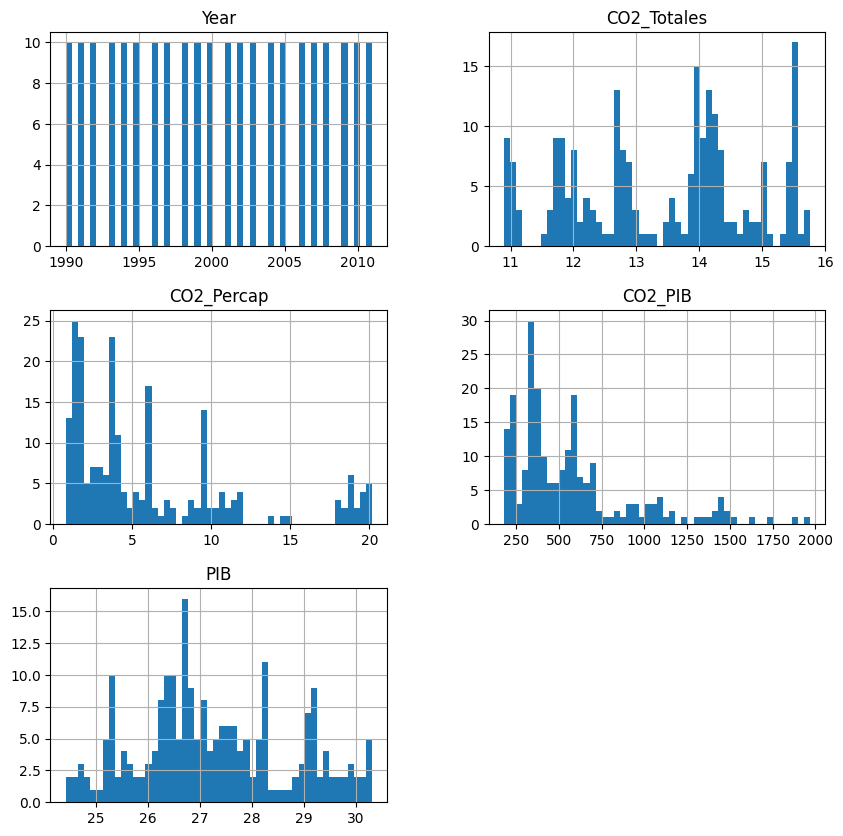

In [29]:
#Histogrma a de variables con algoritmo KNN
df_knn.hist(figsize=(10,10), bins=50)

In [88]:
#### Serie de tiempo emisiones de C02 por Año y País
import plotly.express as px

fig = px.line(df_knn, x='Year', y='CO2_Totales', color='Country Code',
              title='Emisiones de CO₂ Totales por Año y País',
              width=800)
fig.update_layout(title_x=0.5)
fig.show()

In [31]:
#### Serie de tiempo PIB por Año y País
import plotly.express as px

fig = px.line(df_knn, x='Year', y='PIB', color='Country Code',
              title='PIB por Año y País',
              width=1000)
fig.update_layout(title_x=0.5)
fig.show()

In [89]:
# Serie de timpo CO2 Percápita

fig = px.line(df_knn, x='Year', y='CO2_Percap', color='Country Code',
              title='CO2 Percápita por Año y País',
              width=800)
fig.update_layout(title_x=0.5)
fig.show()


**Analisis estadistico**

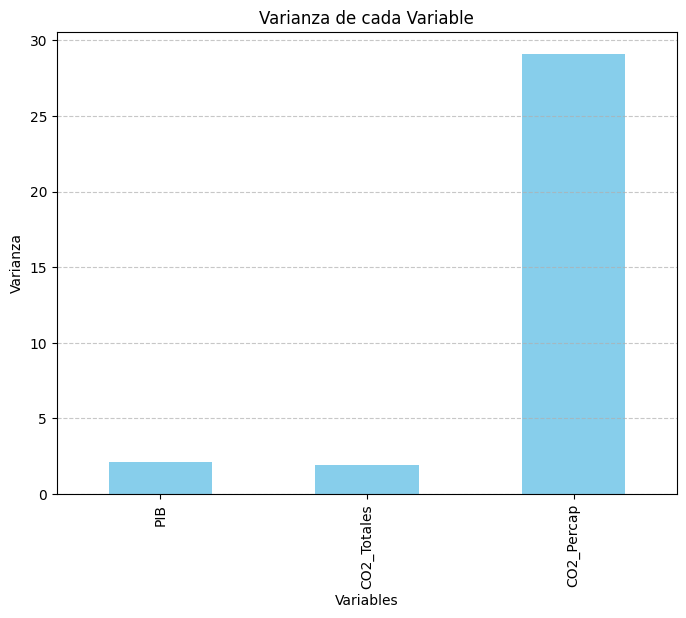

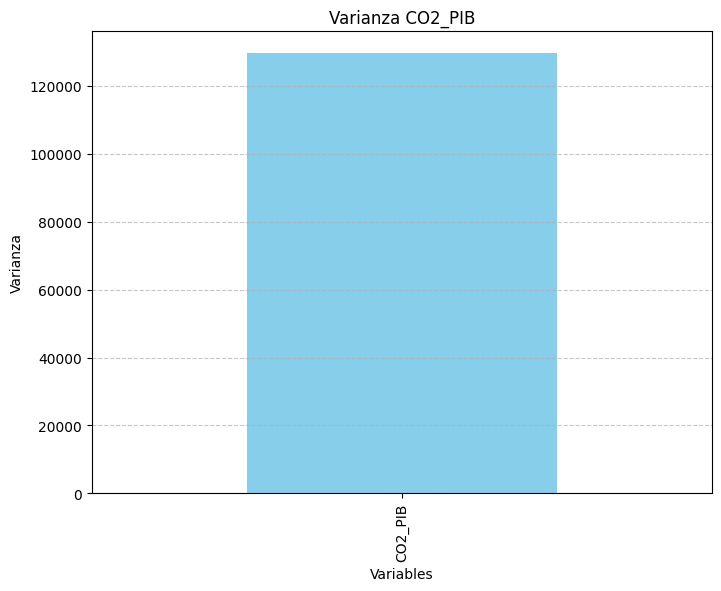

In [33]:
#Analisis Varianzas
Columnas = ['PIB', 'CO2_Totales', 'CO2_Percap']

varianzas = df_knn[Columnas].var()
varianzas

plt.figure(figsize=(8, 6))
varianzas.plot(kind='bar', color='skyblue')
plt.title('Varianza de cada Variable')
plt.xlabel('Variables')
plt.ylabel('Varianza')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

varianza = pd.Series(df_knn['CO2_PIB'].var(), index=['CO2_PIB'])

plt.figure(figsize=(8, 6))
varianza.plot(kind='bar', color='skyblue')
plt.title('Varianza CO2_PIB')
plt.xlabel('Variables')
plt.ylabel('Varianza')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

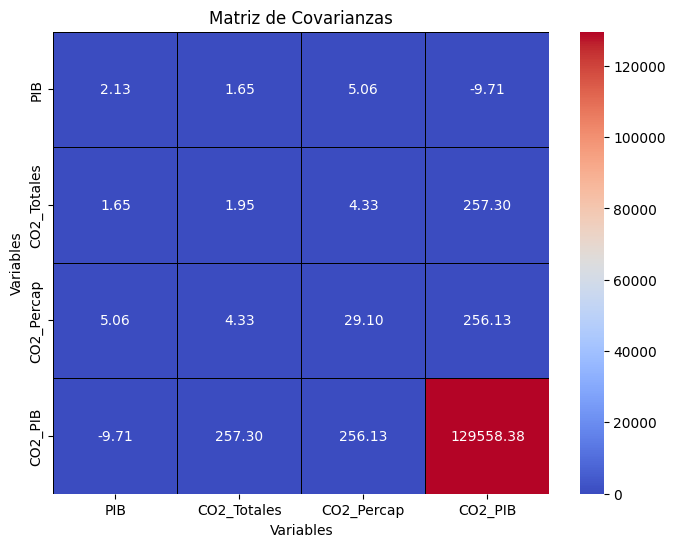

In [34]:
### Analisis Covarianza
import plotly.express as px
import plotly.graph_objects as go
Columna = ['PIB', 'CO2_Totales', 'CO2_Percap', 'CO2_PIB']

covarianzas = df_knn[Columna].cov()


plt.figure(figsize=(8, 6))
sns.heatmap(covarianzas, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('Matriz de Covarianzas')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()





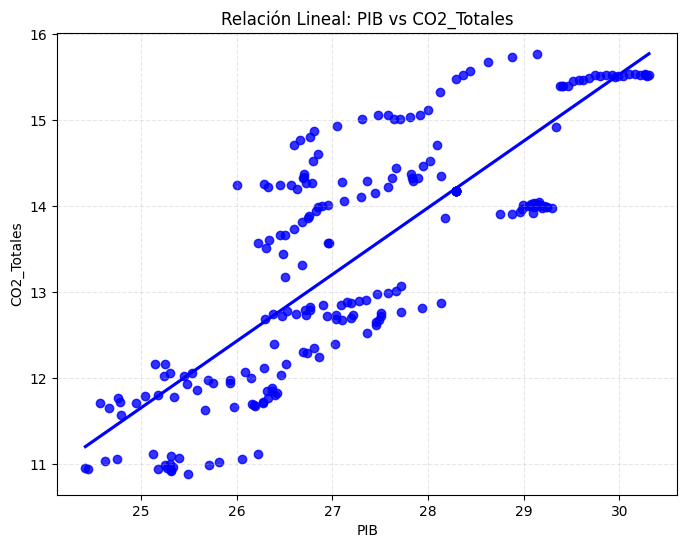

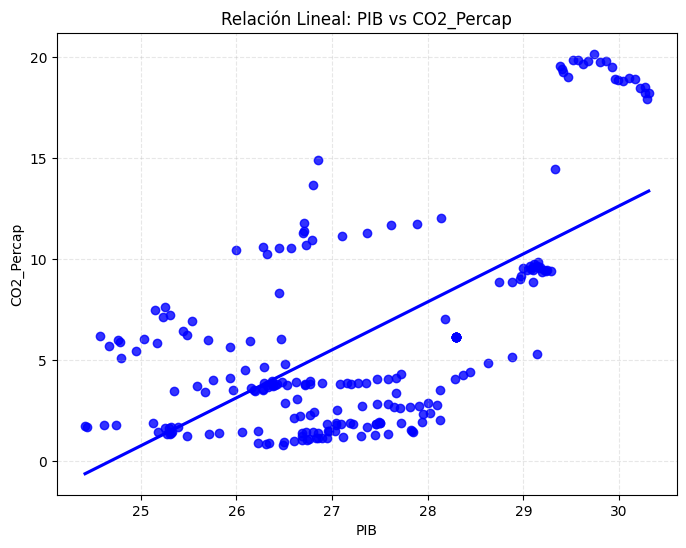

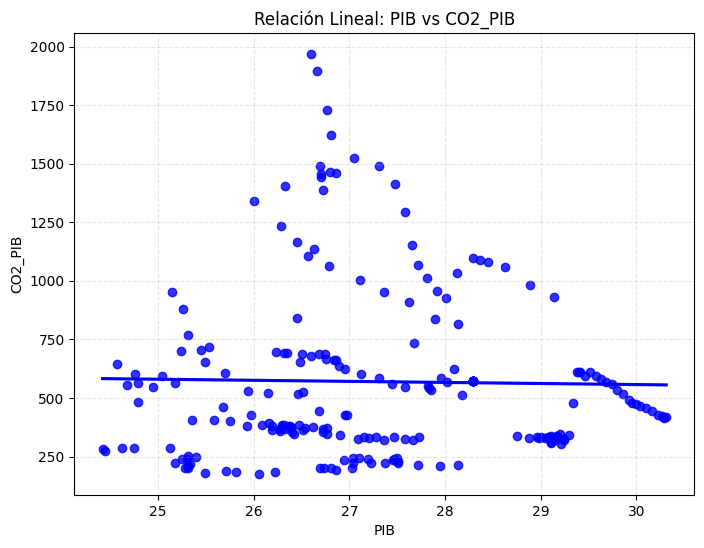

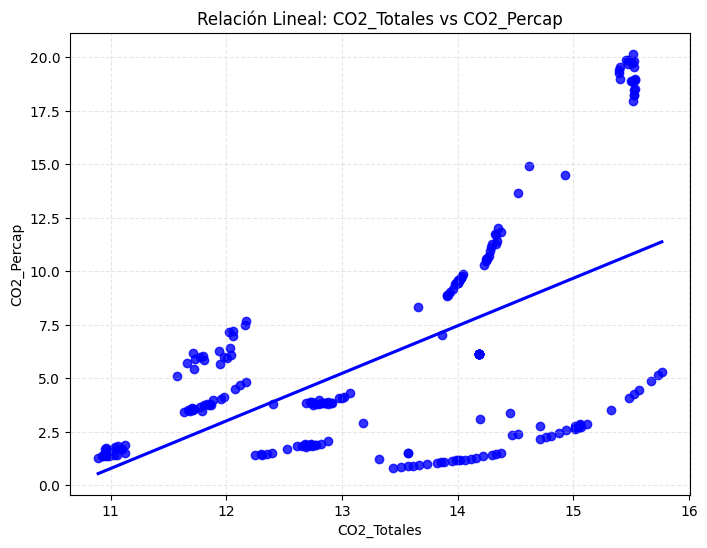

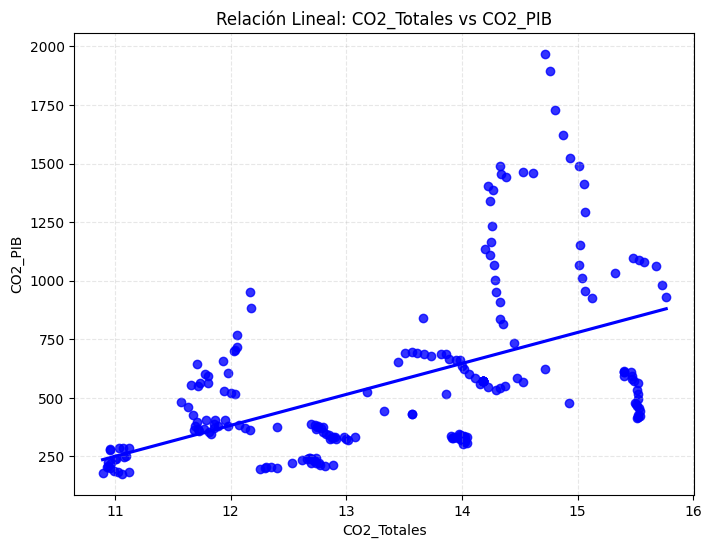

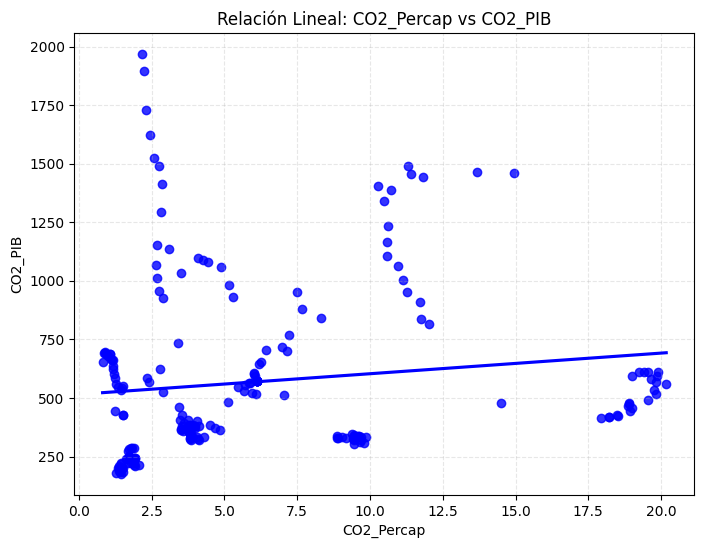

In [35]:
import matplotlib.pyplot as plt
from itertools import combinations

variables = variables = df_knn[['PIB', 'CO2_Totales', 'CO2_Percap', 'CO2_PIB']]
pares = list(combinations(variables, 2))

for x, y in pares:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=x, y=y, data=df_knn, ci=None, color='blue')
    plt.title(f'Relación Lineal: {x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(alpha=0.3, linestyle='--')
    plt.show()


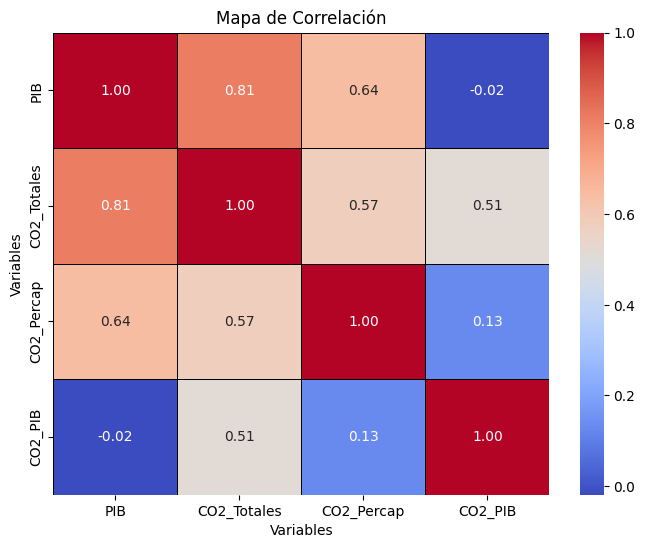

In [36]:
## Correlación
Columnas = ['PIB', 'CO2_Totales', 'CO2_Percap', 'CO2_PIB']
matriz_correlacion= df_knn[Columnas].corr()
matriz_correlacion

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('Mapa de Correlación')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()


# Base de Datos Importaciones y Exportaciones





Las importaciones de bienes y servicios representan el valor de todos los bienes y otros servicios de mercado recibidos del resto del mundo. Incluyen el valor de las mercaderías, fletes, seguros, transporte, viajes, regalías, tarifas de licencia y otros servicios tales como los relativos a las comunicaciones, la construcción, los servicios financieros, los informativos, los empresariales, los personales y los del Gobierno. Excluyen la remuneración de los empleados y los ingresos por inversiones (anteriormente denominados servicios de los factores), como también los pagos de transferencias.

Cargar la base de datos Importaciones


In [37]:
df_importaciones = pd.read_excel("/content/drive/MyDrive/Talento Tech - Analisis de Datos/fuenteDatos/Project/Data_importaciones.xls")
df_importaciones

,Country Name,Country Code,Indicator Code,1990,1991,1992,1993,1994,1995,1996,...,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
0,Aruba,ABW,NE.IMP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,86.464,88.704,...,69.394,68.666,70.063,67.765,76.975,76.448,74.911,73.581,74.638,75.246
1,NaN,AFE,NE.IMP.GNFS.ZS,19.756,19.619,21.180,21.283,24.109,25.961,26.438,...,26.562,27.644,26.131,26.845,28.010,29.376,31.669,35.944,31.559,29.896
2,Afganistán,AFG,NE.IMP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,AFW,NE.IMP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NE.IMP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,48.217,49.580,45.200,41.065,31.157,40.154,48.890,63.689,42.581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,NE.IMP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.540,58.528,60.508
262,"Yemen, Rep. del",YEM,NE.IMP.GNFS.ZS,16.459,30.248,29.939,38.214,29.187,41.958,47.433,...,34.995,37.729,37.944,35.464,35.876,40.818,43.220,43.408,39.746,34.391
263,Sudáfrica,ZAF,NE.IMP.GNFS.ZS,16.673,15.541,15.366,15.784,17.565,19.440,20.425,...,22.814,25.034,21.809,22.886,23.828,27.670,29.166,33.720,24.605,24.623
264,Zambia,ZMB,NE.IMP.GNFS.ZS,NaN,NaN,NaN,NaN,33.700,36.326,35.343,...,39.559,37.783,36.629,37.273,31.590,25.264,32.180,30.536,26.870,27.989


Transformar el DataFrame

In [38]:
df_meltedImpor = df_importaciones.melt(
    id_vars=['Country Code', 'Country Name', 'Indicator Code'],
    var_name='Year',  # Nombre de la nueva columna para los años
    value_name='Value'  # Nombre de la nueva columna para los valores
)

# Ordenar el DataFrame (opcional)
df_meltedImpor = df_meltedImpor.sort_values(by=['Country Code', 'Indicator Code', 'Year'])

# Mostrar el resultado
#print(df_melted.head())
df_meltedImpor.info()
df_meltedImpor

<class 'pandas.core.frame.DataFrame'>
Index: 5586 entries, 0 to 5585
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Code    5586 non-null   object 
 1   Country Name    5544 non-null   object 
 2   Indicator Code  5586 non-null   object 
 3   Year            5586 non-null   object 
 4   Value           4430 non-null   float64
dtypes: float64(1), object(4)
memory usage: 261.8+ KB


,Country Code,Country Name,Indicator Code,Year,Value
0,ABW,Aruba,NE.IMP.GNFS.ZS,1990,NaN
266,ABW,Aruba,NE.IMP.GNFS.ZS,1991,NaN
532,ABW,Aruba,NE.IMP.GNFS.ZS,1992,NaN
798,ABW,Aruba,NE.IMP.GNFS.ZS,1993,NaN
1064,ABW,Aruba,NE.IMP.GNFS.ZS,1994,NaN
...,...,...,...,...,...
4521,ZWE,Zimbabwe,NE.IMP.GNFS.ZS,2006,46.864
4787,ZWE,Zimbabwe,NE.IMP.GNFS.ZS,2007,46.388
5053,ZWE,Zimbabwe,NE.IMP.GNFS.ZS,2008,68.055
5319,ZWE,Zimbabwe,NE.IMP.GNFS.ZS,2009,42.301


Seleccionar los Países a analizar

In [39]:
df_paisesImpor = df_meltedImpor.loc[df_meltedImpor['Country Name'].isin(['China', 'Estados Unidos', 'India', 'Federación de Rusia', 'Japón', 'Brasil','México', 'Argentina', 'Colombia', 'Venezuela'])]
pd.unique(df_paisesImpor['Country Name'])

array(['Argentina', 'Brasil', 'China', 'Colombia', 'India', 'Japón',
       'México', 'Federación de Rusia', 'Estados Unidos', 'Venezuela'],
      dtype=object)

In [40]:
df_paisesImpor = df_meltedImpor.loc[df_meltedImpor['Country Code'].isin(['CHN', 'USA', 'IND', 'RUS', 'JPN', 'BRA','MEX', 'ARG', 'COL', 'VEN'])]
#pd.unique(df_paises['Country name']) # This line is not needed, and was causing confusion

df_paisesImpor = pd.DataFrame(df_paisesImpor) # This is likely not needed, since a slice of a dataframe is already a dataframe, but retained to maintain user's original intent.

# Convertir la columna 'Value' a numérico
df_paisesImpor['Value'] = pd.to_numeric(df_paisesImpor['Value'], errors='coerce')

# Reorganizar el DataFrame usando pivot
df_impor= df_paisesImpor.pivot(index=['Country Code', 'Country Name', 'Year'], columns='Indicator Code', values='Value').reset_index()

# Eliminar nombres de índices en las columnas
df_impor.columns.name = None
df_impor = df_impor.rename_axis(None, axis=1)

df_impor

,Country Code,Country Name,Year,NE.IMP.GNFS.ZS
0,ARG,Argentina,1990,4.631
1,ARG,Argentina,1991,6.078
2,ARG,Argentina,1992,8.133
3,ARG,Argentina,1993,9.314
4,ARG,Argentina,1994,10.604
...,...,...,...,...
205,VEN,Venezuela,2006,22.147
206,VEN,Venezuela,2007,25.069
207,VEN,Venezuela,2008,21.007
208,VEN,Venezuela,2009,20.449


In [41]:
skim(df_impor)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 210    │ │ string      │ 3     │                                                          │
│ │ Number of columns │ 4      │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column            ┃ NA  ┃ NA %   ┃ mean    ┃ sd     ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ NE.IMP.GNFS.ZS    │   0 │      0 │   17.11 │  6.449 │  4.631 │  11.91 │  16.74 │  21.42 │  48.25 │  ▅█▇▂   │  │
│ └───────────────────┴─────┴────────┴─────────┴────────┴────────┴────────┴────────┴────────┴────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Country   │  0 │    0 │ ARG      │ ARG       │ ARG       │ VEN       │          3 │         1 │        210 │  │
│ │ Code      │    │      │          │           │           │           │            │           │            │  │
│ │ Country   │  0 │    0 │ China    │ Federació │ Argentina │ Venezuela │        8.6 │       1.3 │        273 │  │
│ │ Name      │    │      │          │ n de      │           │           │            │           │            │  │
│ │           │    │      │          │ Rusia     │           │           │            │           │            │  │
│ │ Year      │  0 │    0 │ 1990     │ 1990      │ 1990      │ 2010      │          4 │         1 │        210 │  │
│ └───────────┴────┴──────┴──────────┴───────────┴───────────┴───────────┴────────────┴───────────┴────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

Cargar la base de datos de Exportaciones

In [42]:
df_Exportaciones = pd.read_excel("/content/drive/MyDrive/Talento Tech - Analisis de Datos/fuenteDatos/Project/Data_Exportaciones.xlsx")
df_Exportaciones

,Country Name,Country Code,Indicator Code,1990,1991,1992,1993,1994,1995,1996,...,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
0,Aruba,ABW,NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,84.898,86.640,...,70.997,64.564,62.731,64.666,68.075,64.594,65.061,65.529,62.919,60.218
1,NaN,AFE,NE.EXP.GNFS.ZS,20.445,18.620,21.617,22.800,23.798,24.477,25.550,...,27.357,27.899,25.610,25.786,27.726,29.688,32.069,35.696,27.407,29.631
2,Afganistán,AFG,NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,AFW,NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,57.085,54.321,58.380,65.526,63.468,67.906,72.475,58.757,61.543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.191,19.228,21.669
262,"Yemen, Rep. del",YEM,NE.EXP.GNFS.ZS,11.168,17.674,16.212,19.927,39.777,45.486,38.506,...,35.897,37.001,36.439,36.382,40.897,41.259,35.903,37.837,28.325,29.995
263,Sudáfrica,ZAF,NE.EXP.GNFS.ZS,21.539,19.341,18.955,19.914,19.549,20.038,21.775,...,26.357,28.431,23.915,22.758,23.600,26.098,27.959,32.255,24.983,25.783
264,Zambia,ZMB,NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,32.950,32.901,28.479,...,25.110,27.134,25.684,33.540,30.611,32.593,33.591,28.919,29.251,37.026


In [43]:
df_meltedExpor = df_Exportaciones.melt(
    id_vars=['Country Code', 'Country Name', 'Indicator Code'],
    var_name='Year',  # Nombre de la nueva columna para los años
    value_name='Value'  # Nombre de la nueva columna para los valores
)

# Ordenar el DataFrame (opcional)
df_meltedExpor = df_meltedExpor.sort_values(by=['Country Code', 'Indicator Code', 'Year'])

# Mostrar el resultado
#print(df_melted.head())
df_meltedExpor.info()
df_meltedExpor

<class 'pandas.core.frame.DataFrame'>
Index: 5586 entries, 0 to 5585
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Code    5586 non-null   object 
 1   Country Name    5544 non-null   object 
 2   Indicator Code  5586 non-null   object 
 3   Year            5586 non-null   object 
 4   Value           4393 non-null   float64
dtypes: float64(1), object(4)
memory usage: 261.8+ KB


,Country Code,Country Name,Indicator Code,Year,Value
0,ABW,Aruba,NE.EXP.GNFS.ZS,1990,NaN
266,ABW,Aruba,NE.EXP.GNFS.ZS,1991,NaN
532,ABW,Aruba,NE.EXP.GNFS.ZS,1992,NaN
798,ABW,Aruba,NE.EXP.GNFS.ZS,1993,NaN
1064,ABW,Aruba,NE.EXP.GNFS.ZS,1994,NaN
...,...,...,...,...,...
4521,ZWE,Zimbabwe,NE.EXP.GNFS.ZS,2006,35.956
4787,ZWE,Zimbabwe,NE.EXP.GNFS.ZS,2007,37.785
5053,ZWE,Zimbabwe,NE.EXP.GNFS.ZS,2008,41.467
5319,ZWE,Zimbabwe,NE.EXP.GNFS.ZS,2009,19.477


In [44]:
df_paisesExport = df_meltedExpor.loc[df_meltedExpor['Country Name'].isin(['China', 'Estados Unidos', 'India', 'Federación de Rusia', 'Japón', 'Brasil','México', 'Argentina', 'Colombia', 'Venezuela'])]
df_paisesExport
pd.unique(df_paisesExport['Country Name'])

array(['Argentina', 'Brasil', 'China', 'Colombia', 'India', 'Japón',
       'México', 'Federación de Rusia', 'Estados Unidos', 'Venezuela'],
      dtype=object)

In [45]:
df_paisesExport = pd.DataFrame(df_paisesExport)

# Convertir la columna 'Value' a numérico
df_paisesExport['Value'] = pd.to_numeric(df_paisesExport['Value'], errors='coerce')

# Reorganizar el DataFrame usando pivot
df_export = df_paisesExport.pivot(index=['Country Code', 'Country Name', 'Year'], columns='Indicator Code', values='Value').reset_index()

# Eliminar nombres de índices en las columnas
df_export.columns.name = None
df_export = df_export.rename_axis(None, axis=1)

df_export

,Country Code,Country Name,Year,NE.EXP.GNFS.ZS
0,ARG,Argentina,1990,10.360
1,ARG,Argentina,1991,7.675
2,ARG,Argentina,1992,6.598
3,ARG,Argentina,1993,6.909
4,ARG,Argentina,1994,7.530
...,...,...,...,...
205,VEN,Venezuela,2006,36.519
206,VEN,Venezuela,2007,31.131
207,VEN,Venezuela,2008,30.822
208,VEN,Venezuela,2009,18.072


In [46]:
skim(df_export)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 210    │ │ string      │ 3     │                                                          │
│ │ Number of columns │ 4      │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column            ┃ NA  ┃ NA %   ┃ mean    ┃ sd     ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩  │
│ │ NE.EXP.GNFS.ZS    │   0 │      0 │   18.66 │  9.275 │  6.598 │  10.69 │  16.43 │  24.73 │  62.32 │  █▅▃▁   │  │
│ └───────────────────┴─────┴────────┴─────────┴────────┴────────┴────────┴────────┴────────┴────────┴─────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Country   │  0 │    0 │ ARG      │ ARG       │ ARG       │ VEN       │          3 │         1 │        210 │  │
│ │ Code      │    │      │          │           │           │           │            │           │            │  │
│ │ Country   │  0 │    0 │ China    │ Federació │ Argentina │ Venezuela │        8.6 │       1.3 │        273 │  │
│ │ Name      │    │      │          │ n de      │           │           │            │           │            │  │
│ │           │    │      │          │ Rusia     │           │           │            │           │            │  │
│ │ Year      │  0 │    0 │ 1990     │ 1990      │ 1990      │ 2010      │          4 │         1 │        210 │  │
│ └───────────┴────┴──────┴──────────┴───────────┴───────────┴───────────┴────────────┴───────────┴────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

Unir los DataFrame

In [47]:
df_comercio = pd.merge(df_export, df_impor, on=['Year', 'Country Code'])
df_comercio
df_comercio = df_comercio.rename(columns={'NE.EXP.GNFS.ZS': 'Exportaciones', 'NE.IMP.GNFS.ZS': 'Importaciones',"Country Name_x":"Country name"})
df_comercio = df_comercio.drop(columns=['Country Name_y'])
df_comercio


,Country Code,Country name,Year,Exportaciones,Importaciones
0,ARG,Argentina,1990,10.360,4.631
1,ARG,Argentina,1991,7.675,6.078
2,ARG,Argentina,1992,6.598,8.133
3,ARG,Argentina,1993,6.909,9.314
4,ARG,Argentina,1994,7.530,10.604
...,...,...,...,...,...
205,VEN,Venezuela,2006,36.519,22.147
206,VEN,Venezuela,2007,31.131,25.069
207,VEN,Venezuela,2008,30.822,21.007
208,VEN,Venezuela,2009,18.072,20.449


In [48]:
pd.unique(df_comercio['Country name'])

array(['Argentina', 'Brasil', 'China', 'Colombia', 'India', 'Japón',
       'México', 'Federación de Rusia', 'Estados Unidos', 'Venezuela'],
      dtype=object)

In [49]:
pd.unique(df_knn['Country name'])

['Argentina', 'Brazil', 'China', 'Colombia', 'India', 'Japan', 'Mexico', 'Russian Federation', 'United States', 'Venezuela, RB']
Categories (10, object): ['Argentina', 'Brazil', 'China', 'Colombia', ..., 'Mexico',
                          'Russian Federation', 'United States', 'Venezuela, RB']

In [50]:
# Reemplaza de nombre de paises de español a Ingles

df_comercio['Country name'] = df_comercio['Country name'].replace({
    'Estados Unidos': 'United States',
    'China': 'China',
    "Brasil":"Brazil",
    'India': 'India',
    'Federación de Rusia': 'Russian Federation',
    'Japón': 'Japan',
    'México': 'Mexico',
    'Argentina': 'Argentina',
    'Colombia': 'Colombia',
    'Venezuela': 'Venezuela, RB'})
pd.unique(df_comercio['Country name'])

array(['Argentina', 'Brazil', 'China', 'Colombia', 'India', 'Japan',
       'Mexico', 'Russian Federation', 'United States', 'Venezuela, RB'],
      dtype=object)

Crear el índice de Apertura

In [51]:
df_comercio['Indice_Apertura'] = df_comercio['Exportaciones'] + df_comercio['Importaciones']
df_comercio

,Country Code,Country name,Year,Exportaciones,Importaciones,Indice_Apertura
0,ARG,Argentina,1990,10.360,4.631,14.991
1,ARG,Argentina,1991,7.675,6.078,13.753
2,ARG,Argentina,1992,6.598,8.133,14.731
3,ARG,Argentina,1993,6.909,9.314,16.223
4,ARG,Argentina,1994,7.530,10.604,18.134
...,...,...,...,...,...,...
205,VEN,"Venezuela, RB",2006,36.519,22.147,58.666
206,VEN,"Venezuela, RB",2007,31.131,25.069,56.199
207,VEN,"Venezuela, RB",2008,30.822,21.007,51.829
208,VEN,"Venezuela, RB",2009,18.072,20.449,38.521


In [52]:
df_comercio["Year"]=df_comercio["Year"].astype("int32")
df_comercio["Country Code"]=df_comercio["Country Code"].astype("category")
df_comercio["Country name"]=df_comercio["Country name"].astype("category")
df_comercio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Country Code     210 non-null    category
 1   Country name     210 non-null    category
 2   Year             210 non-null    int32   
 3   Exportaciones    210 non-null    float64 
 4   Importaciones    210 non-null    float64 
 5   Indice_Apertura  210 non-null    float64 
dtypes: category(2), float64(3), int32(1)
memory usage: 7.0 KB


In [75]:
# Serie de timpo Exportaciones e Importaciones

fig = px.line(df_comercio, x='Year', y='Exportaciones', color='Country Code',
              title='Exportaciones',
              width=1000)
fig.update_layout(title_x=0.5)
fig.show()

# Serie de timpo Exportaciones e Importaciones

fig = px.line(df_comercio, x='Year', y='Importaciones', color='Country Code',
              title='Importaciones',
              width=1000)
fig.update_layout(title_x=0.5)
fig.show()

# Serie de tiempo Indice de Apertura

fig = px.line(df_comercio, x='Year', y='Indice_Apertura', color='Country Code',
              title='Indice de Apertura',
              width=1000)

fig.update_layout(title_x=0.5)

fig.show()

In [54]:
# @title
# Now perform the merge
df_analisis = pd.merge(df_knn, df_comercio, on=['Country Code', 'Year',"Country name"])
df_analisis

df_analisis

,Country Code,Country name,Year,CO2_Totales,CO2_Percap,CO2_PIB,PIB,Exportaciones,Importaciones,Indice_Apertura
0,ARG,Argentina,1990,11.632,3.450,462.561,25.675,10.360,4.631,14.991
1,ARG,Argentina,1991,11.670,3.536,426.615,25.969,7.675,6.078,13.753
2,ARG,Argentina,1992,11.707,3.621,395.522,26.156,6.598,8.133,14.731
3,ARG,Argentina,1993,11.684,3.490,364.734,26.190,6.909,9.314,16.223
4,ARG,Argentina,1994,11.723,3.584,358.397,26.274,7.530,10.604,18.134
...,...,...,...,...,...,...,...,...,...,...
205,VEN,"Venezuela, RB",2006,11.942,5.682,530.004,25.935,36.519,22.147,58.666
206,VEN,"Venezuela, RB",2007,12.005,5.951,521.832,26.146,31.131,25.069,56.199
207,VEN,"Venezuela, RB",2008,12.041,6.069,516.218,26.463,30.822,21.007,51.829
208,VEN,"Venezuela, RB",2009,13.178,2.894,526.088,26.511,18.072,20.449,38.521


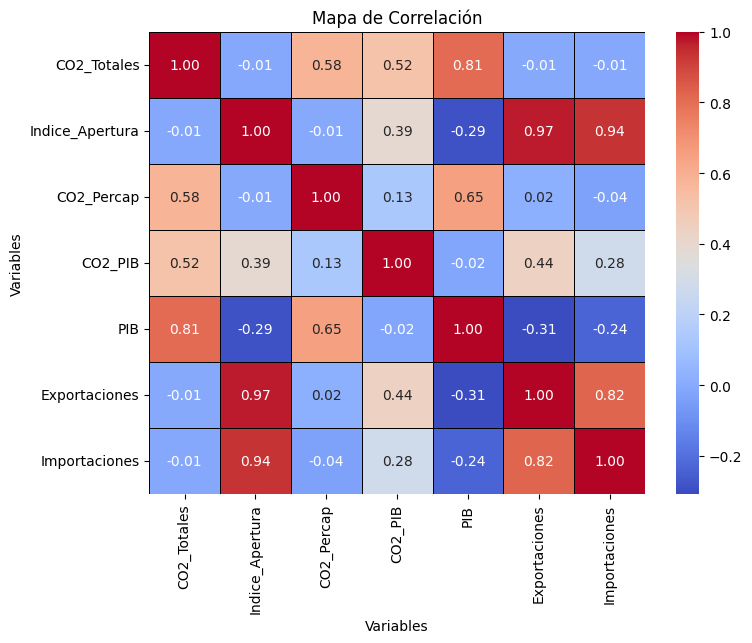

In [55]:
Columnas = ['CO2_Totales', 'Indice_Apertura', 'CO2_Percap', 'CO2_PIB', 'PIB', 'Exportaciones', 'Importaciones'  ]

matriz_correlacion= df_analisis[Columnas].corr()
matriz_correlacion

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('Mapa de Correlación')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()



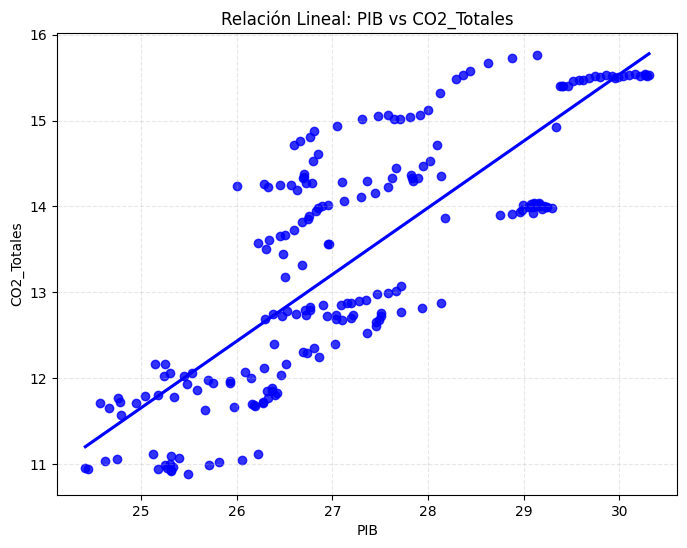

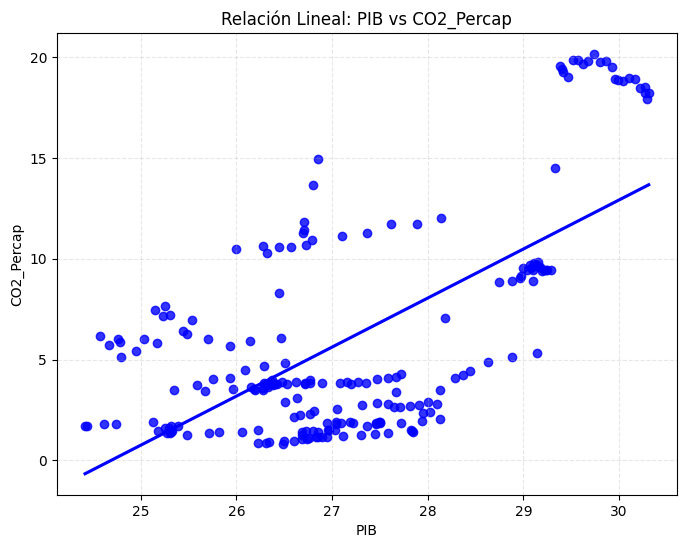

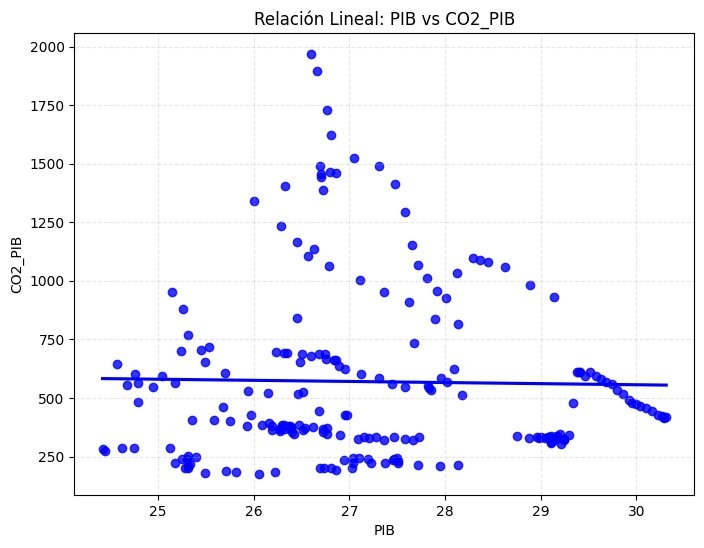

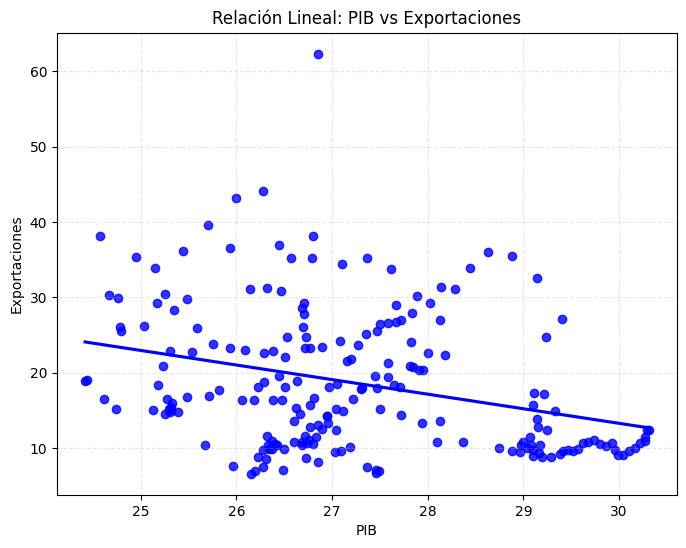

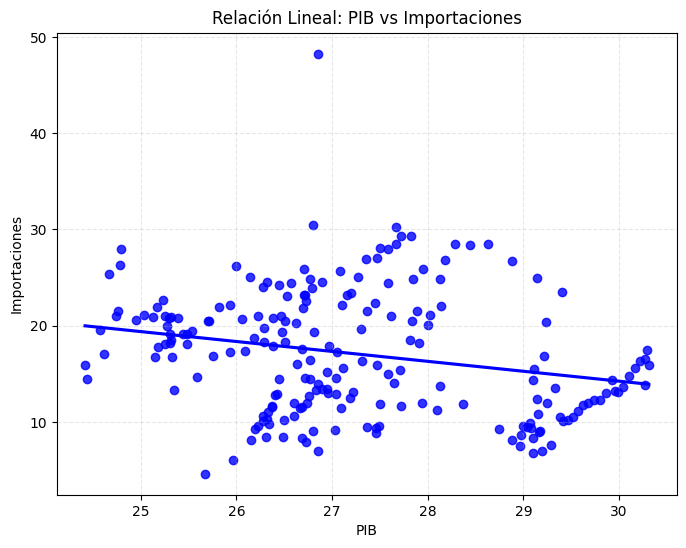

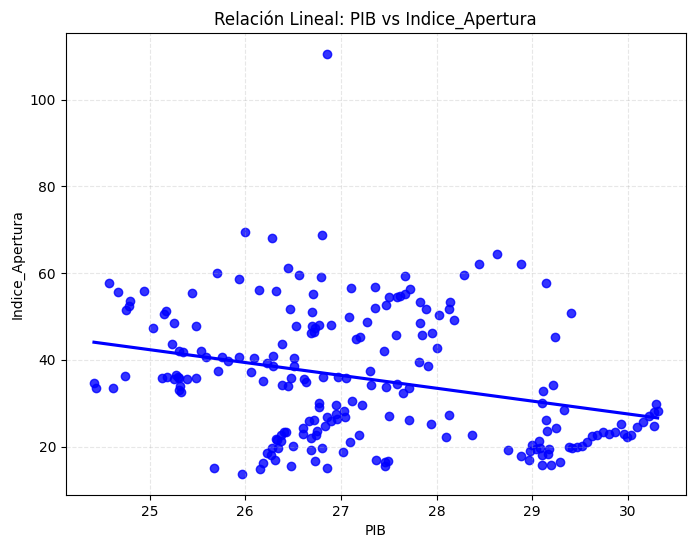

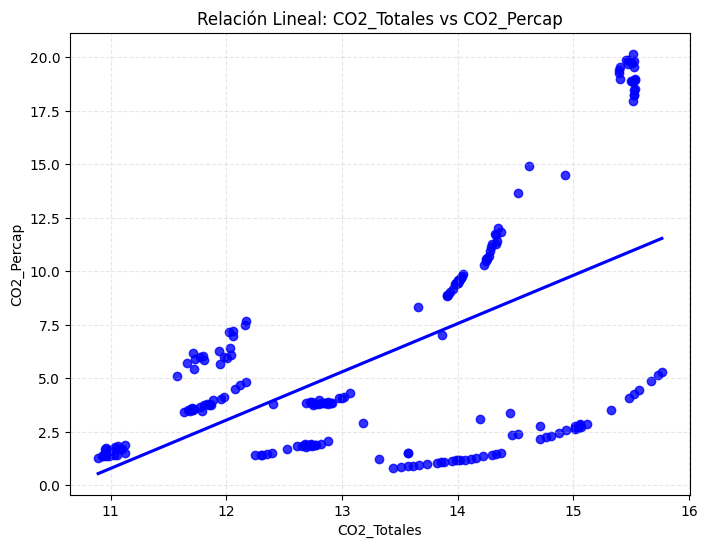

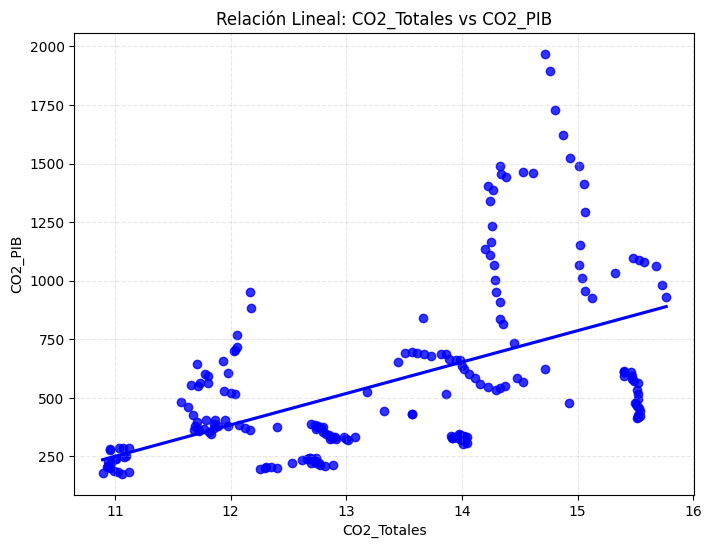

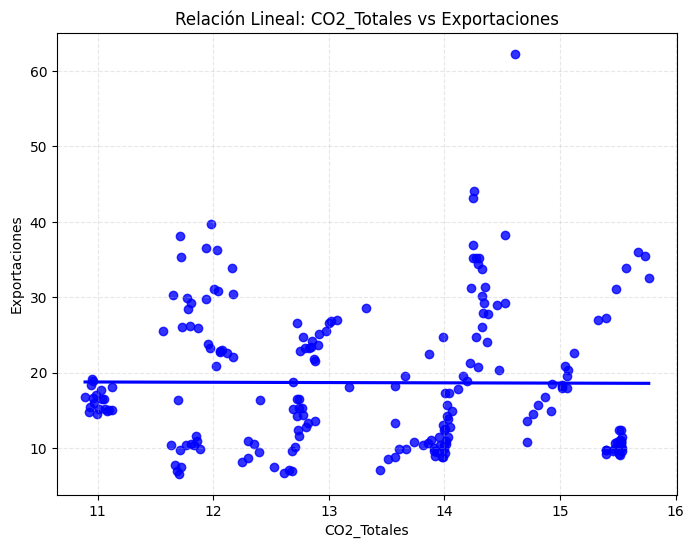

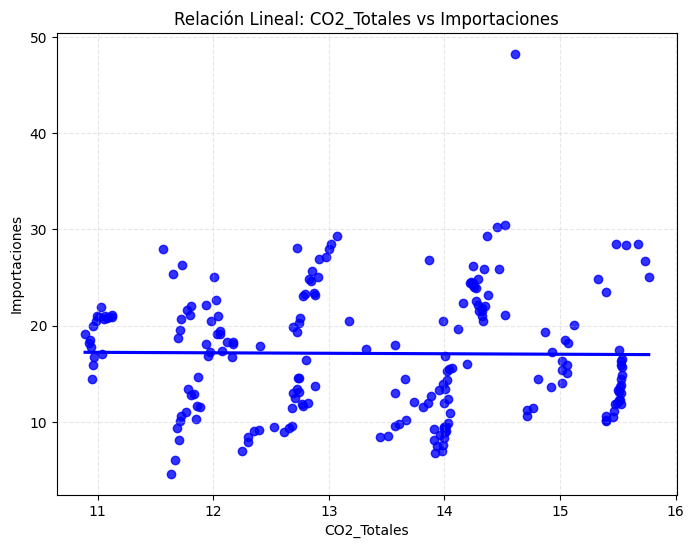

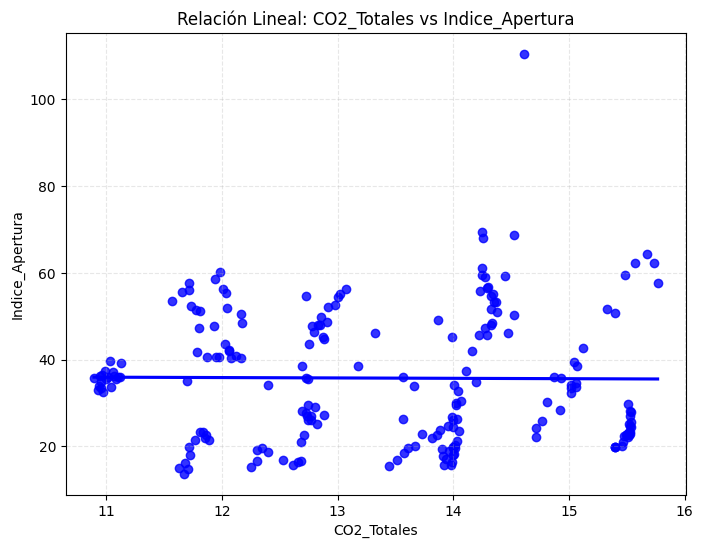

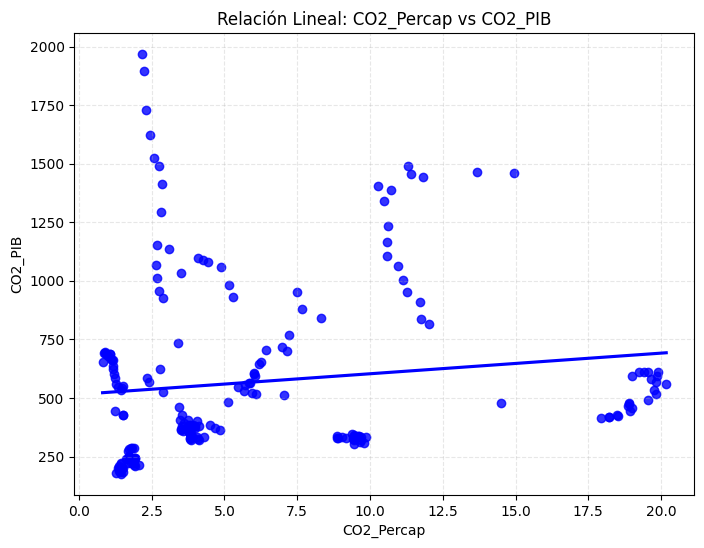

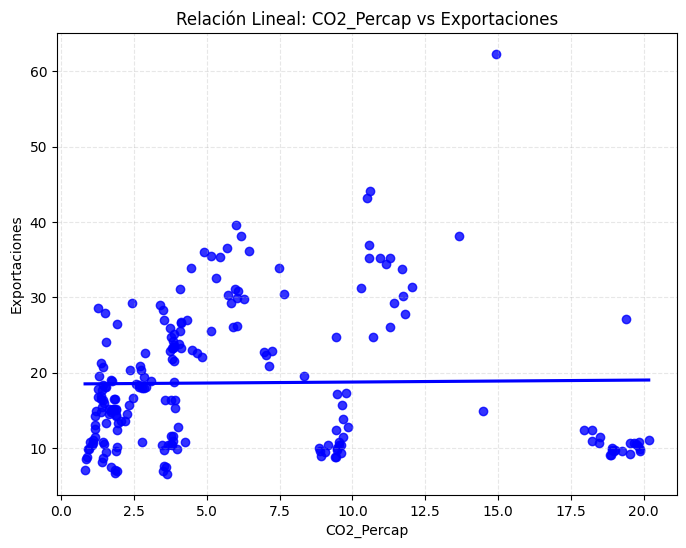

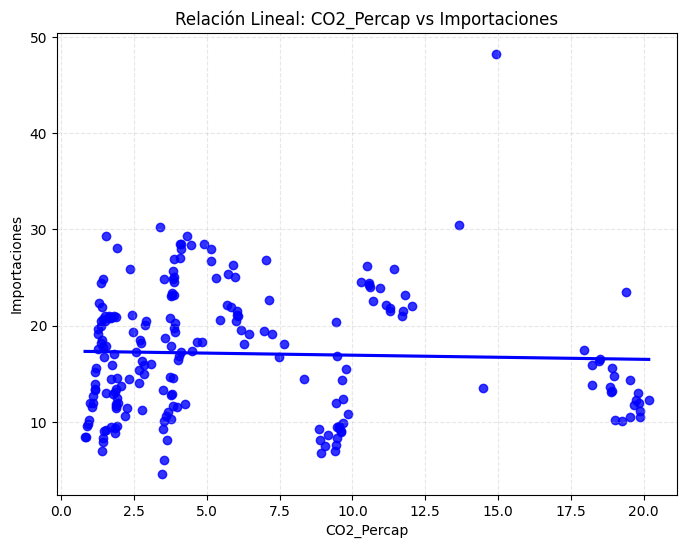

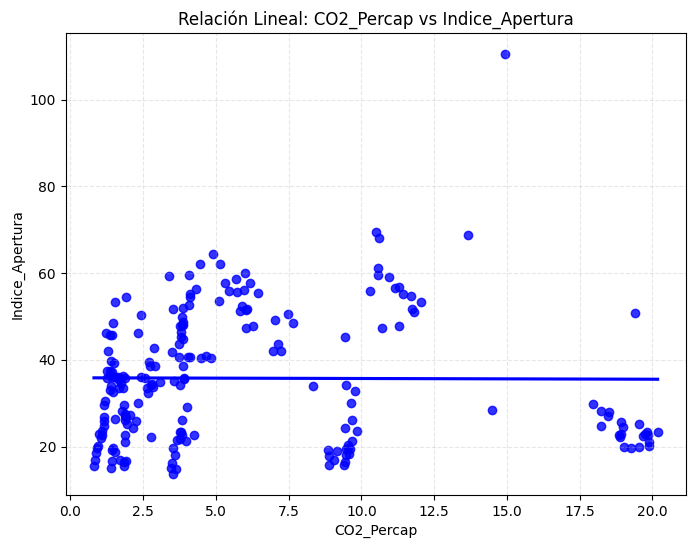

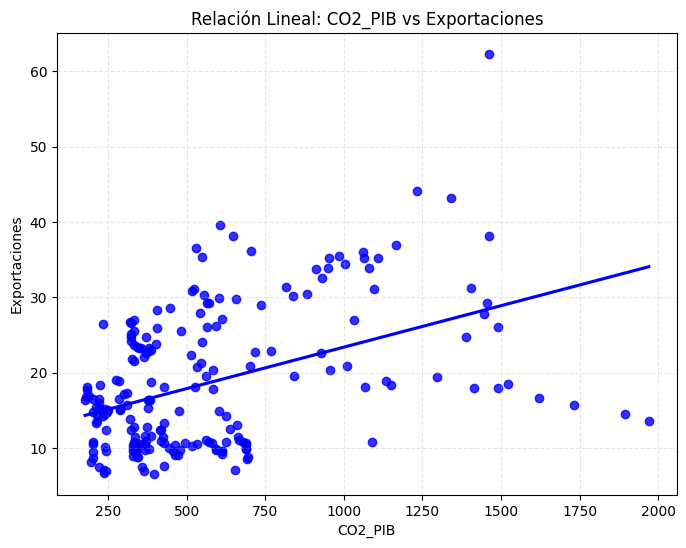

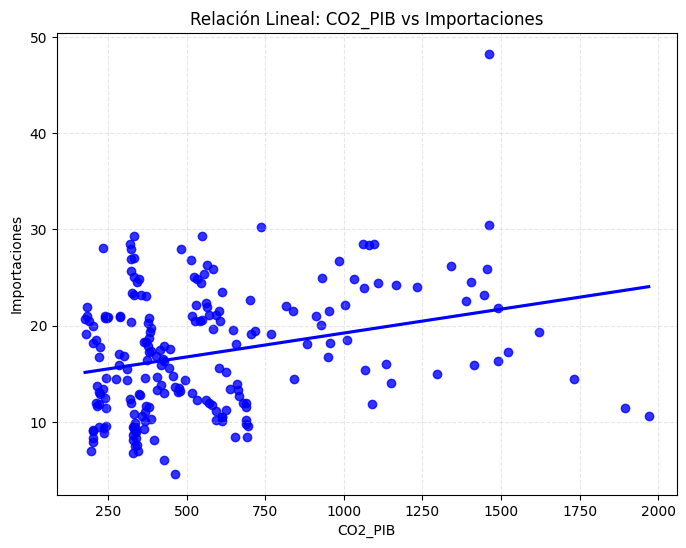

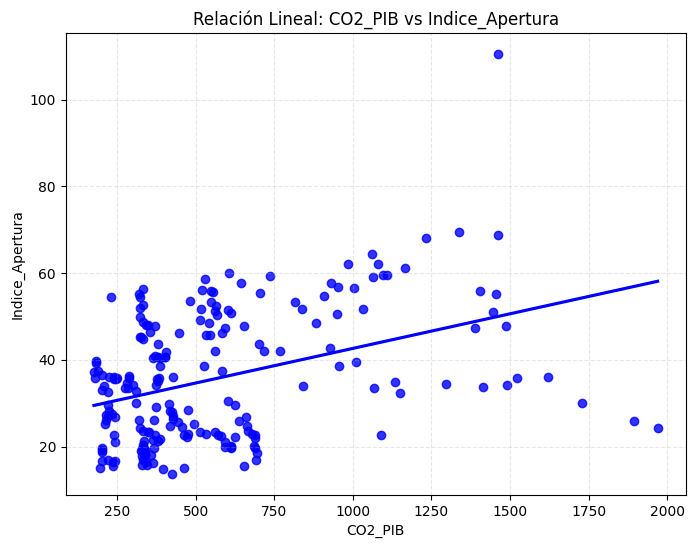

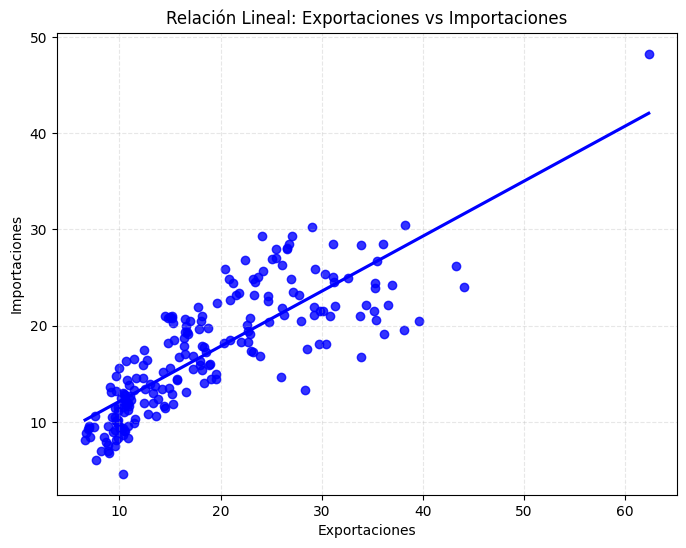

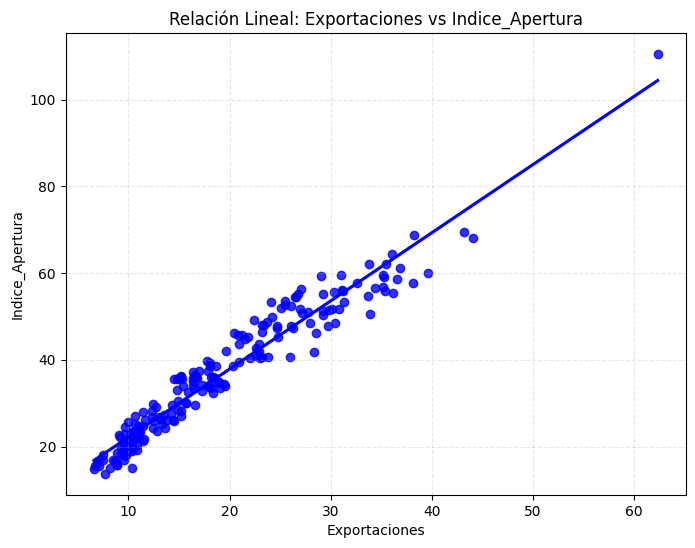

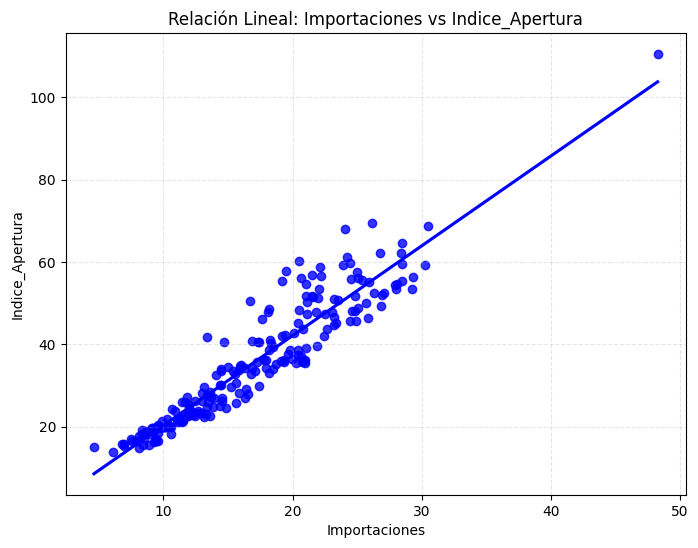

In [56]:
variables = variables = df_analisis[['PIB', 'CO2_Totales', 'CO2_Percap', 'CO2_PIB', 'Exportaciones', 'Importaciones', 'Indice_Apertura']]
pares = list(combinations(variables, 2))

for x, y in pares:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=x, y=y, data=df_analisis, ci=None, color='blue')
    plt.title(f'Relación Lineal: {x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(alpha=0.3, linestyle='--')
    plt.show()


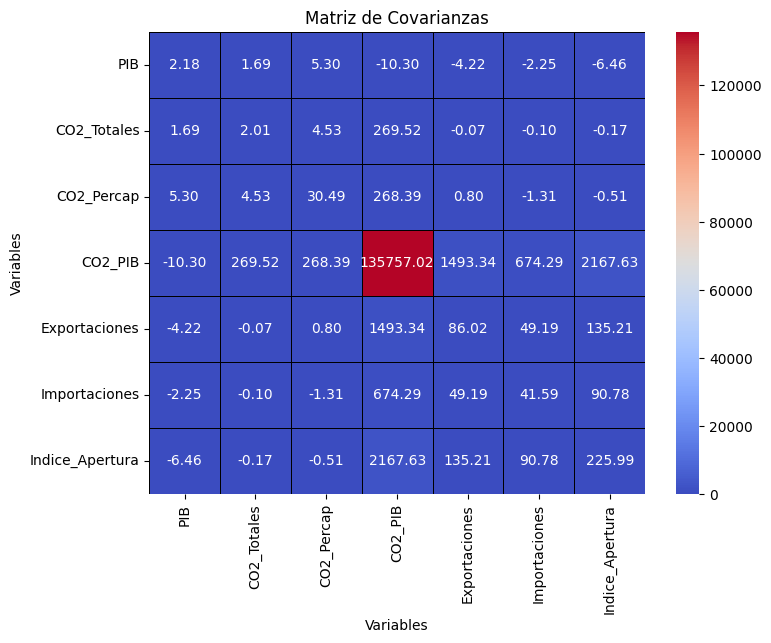

In [57]:
# Covarianza entre las variables

columnasCova = ['PIB', 'CO2_Totales', 'CO2_Percap', 'CO2_PIB', 'Exportaciones', 'Importaciones', 'Indice_Apertura']
df_covarianza = df_analisis[columnasCova]
covarianza = df_covarianza.cov()

plt.figure(figsize=(8, 6))
sns.heatmap(covarianza, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black')
plt.title('Matriz de Covarianzas')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()

In [58]:

# Exportar el DataFrame  df_analisis a un archivo CSV
df_analisis.to_csv('df_analisis.csv', index=False)


In [59]:
df_analisis

,Country Code,Country name,Year,CO2_Totales,CO2_Percap,CO2_PIB,PIB,Exportaciones,Importaciones,Indice_Apertura
0,ARG,Argentina,1990,11.632,3.450,462.561,25.675,10.360,4.631,14.991
1,ARG,Argentina,1991,11.670,3.536,426.615,25.969,7.675,6.078,13.753
2,ARG,Argentina,1992,11.707,3.621,395.522,26.156,6.598,8.133,14.731
3,ARG,Argentina,1993,11.684,3.490,364.734,26.190,6.909,9.314,16.223
4,ARG,Argentina,1994,11.723,3.584,358.397,26.274,7.530,10.604,18.134
...,...,...,...,...,...,...,...,...,...,...
205,VEN,"Venezuela, RB",2006,11.942,5.682,530.004,25.935,36.519,22.147,58.666
206,VEN,"Venezuela, RB",2007,12.005,5.951,521.832,26.146,31.131,25.069,56.199
207,VEN,"Venezuela, RB",2008,12.041,6.069,516.218,26.463,30.822,21.007,51.829
208,VEN,"Venezuela, RB",2009,13.178,2.894,526.088,26.511,18.072,20.449,38.521


# Graficación a StreamLit


**Instalación de Recursos**

In [76]:
# Instalación de Streamlit, una biblioteca de Python para construir aplicaciones web interactivas.
!pip install -q streamlit


In [77]:
pip install pydeck folium streamlit-folium

In [78]:
# Instalación de localtunnel, una herramienta para exponer servidores locales a la web
!npm install -q localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇
up to date, audited 23 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠇

In [79]:
# Inicio de la aplicación Streamlit en segundo plano y redirección de los logs a un archivo.
!streamlit run app.py &>/content/logs.txt &

In [80]:
# Uso de localtunnel para exponer el puerto local 8501 a Internet.
!npx localtunnel --port 8501

⠙⠹your url is: https://four-walls-design.loca.lt
^C


In [81]:
# Instalación de pyngrok, una biblioteca para integrar ngrok (otra herramienta para exponer servidores locales).
!pip install pyngrok

^C


In [82]:
# Nota: Es necesario crear una cuenta en ngrok.com para obtener un token de autenticación único.
# Esto permite exponer el servidor local a Internet.
# Una vez creada la cuenta, copia tu token desde el panel de ngrok y reemplaza el valor en la siguiente línea.

from pyngrok import ngrok
ngrok.set_auth_token("2uvMdYtbyLkCgZZieBEIqHNywoH_2ckAnre2h6bYVdrVKamzm")

In [83]:
# Actualización de la biblioteca pyngrok en caso de que no esté actualizada.
!pip install --upgrade pyngrok

In [84]:
# Creación de una conexión pública al puerto local 8501 y obtención de la URL pública.
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://807c-34-123-218-42.ngrok-free.app" -> "http://localhost:8501"


In [87]:
#Escritura de un nuevo archivo "app.py" con un ejemplo más elaborado para crear un mapa interactivo.

%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import geopandas as gpd
import plotly.express as px
import pydeck as pdk
import folium
from streamlit_folium import st_folium
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns

st.set_page_config(layout="wide")

#-------------------------------------------------------------------------------
#Cargue de DataFrame Depurados
# Cargar el archivo CSV
df = pd.read_csv("df_analisis.csv")
#-------------------------------------------------------------------------------
# Creacion de menu de navegacion
st.sidebar.image("/content/logoTalentoTech.png", use_container_width=True)
# Configurar el menú de navegación
menu = ["Resumen", "Análisis Exploratorio", "Análisis Estádistico","Primer Prototipo"]
opcion = st.sidebar.selectbox("Seleccione una opción", menu)
#-------------------------------------------------------------------------------
# Filtros interactivos
st.sidebar.header("Opciones de filtro")

countries = df['Country name'].unique()
selected_countries = st.sidebar.multiselect('Selecciona países:', countries, default=countries[:10])
years = st.sidebar.slider('Selecciona rango de años:', min_value=int(df['Year'].min()), max_value=int(df['Year'].max()), value=(1990, 2010))

filtered_df = df[(df['Country name'].isin(selected_countries)) & (df['Year'].between(years[0], years[1]))]
#-------------------------------------------------------------------------------

#-------------------------------------------------------------------------------

if opcion == "Resumen":
  st.title("Influencia Del Comercio Internacional de los paises mas contaminantes y de latinoamerica")

  multi = '''En la sección **Análisis Exploratorio**, se realizó un examen detallado de los datos mediante código en Python, utilizando librerías como pandas y numpy. Este análisis permitió explorar la composición del DataFrame, sus columnas y relaciones clave. A partir de ello, se generaron las siguientes gráficas para visualizar los resultados.'''
  st.markdown(multi)

#-------------------------------------------------------------------------------
  # Agregar un paso para agrupar datos por país y sumar emisiones por rango de años
  emissions_by_country = filtered_df.groupby(['Country name', 'Country Code'], as_index=False)['CO2_Totales'].sum()

# Crear el mapa mundi interactivo con colores rojo-verde
  fig = px.choropleth(
      emissions_by_country,
      locations='Country Code',          # Código del país para asociar con el mapa
      color='CO2_Totales',               # Variable que determina los colores
      hover_name='Country name',         # Información mostrada al pasar el ratón
      color_continuous_scale='RdYlGn_r',   # Escala de colores: rojo (más contaminante) -> amarillo -> verde (menos contaminante)
      title='Emisiones Totales de CO2 por País (1990-2010)',
  )

  # Ajustar el diseño del mapa
  fig.update_layout(
      geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
      coloraxis_colorbar=dict(title="CO2 Totales"),
      width=1200,  # Ancho del mapa (en píxeles)
      height=800,  # Altura del mapa (en píxeles)
      title_font_size=20,  # Tamaño de la fuente del título
      margin={"r": 0, "t": 50, "l": 0, "b": 0}  # Márgenes para aprovechar el espacio
  )

  # Mostrar el mapa en Streamlit
  st.plotly_chart(fig, use_container_width=True)
  st.markdown("Mapa Interactivo: Emisiones de CO2 por País")
#-------------------------------------------------------------------------------
if opcion == "Análisis Exploratorio":
  st.title("Análisis Exploratorio")
  multiExploratorio = '''En la sección **Análisis Exploratorio**, se realizó un examen detallado de los datos mediante código en Python, utilizando librerías como pandas y numpy. Este análisis permitió explorar la composición del DataFrame, sus columnas y relaciones clave. A partir de ello, se generaron las siguientes gráficas para visualizar los resultados.'''
  st.markdown(multiExploratorio)

    # Diseñar un layout de cuadrícula (2x2)
  col1, col2 = st.columns(2)

    # Gráfica 1: Distribución de emisiones de CO2 (Histograma)
  with col1:
        st.subheader("Distribución de Emisiones de CO2")
        fig1 = px.histogram(filtered_df, x="CO2_Totales", nbins=10, title="Distribución de CO2 Totales", color_discrete_sequence=["red"])
        fig1.update_layout(title_font_size=14)
        st.plotly_chart(fig1, use_container_width=True)

    # Gráfica 2: Emisiones por países (Barras)
  with col2:
        st.subheader("Emisiones de CO2 por País")
        fig2 = px.bar(filtered_df, x="Country name", y="CO2_Totales", color="CO2_Totales", title="Países con Emisiones Totales de CO2", color_continuous_scale="Reds")
        fig2.update_layout(title_font_size=14)
        st.plotly_chart(fig2, use_container_width=True)

    # Gráfica 3: Tendencias temporales de emisiones (Línea)
  with col1:
        st.subheader("Tendencia Temporal de Emisiones")
        fig3 = px.line(filtered_df, x="Year", y="CO2_Totales", color="Country name", title="Evolución de Emisiones por País", line_shape="linear")
        fig3.update_layout(title_font_size=14)
        st.plotly_chart(fig3, use_container_width=True)

    # Gráfica 4: Relación entre CO2 y PIB (Dispersión)
  with col2:
        st.subheader("Relación entre CO2 y PIB")
        fig4 = px.scatter(filtered_df, x="PIB", y="CO2_Totales", color="Country name", size="CO2_Totales", title="CO2 vs PIB", color_discrete_sequence=["red"])
        fig4.update_layout(title_font_size=14)
        st.plotly_chart(fig4, use_container_width=True)


  # Clasificar países como 'Latinoamérica' o 'Globales más contaminantes'
  latam_countries = ["Argentina", "Brazil", "Chile", "Colombia", "Mexico", "Peru"]  # Lista de países de LATAM
  global_top_emitters = ["China", "USA", "India", "Russia", "Japan"]  # Principales contaminantes globales

  # Crear la columna 'Categoría' en el DataFrame
  filtered_df["Categoría"] = filtered_df["Country name"].apply(
      lambda x: "Latinoamérica" if x in latam_countries else ("Global más contaminante" if x in global_top_emitters else "Otros")
  )

  # Agregar emisiones totales por categoría y año
  df_grouped = filtered_df.groupby(["Year", "Categoría"])["CO2_Totales"].sum().reset_index()

  # Pivotear datos para el gráfico de área
  df_pivot = df_grouped.pivot(index="Year", columns="Categoría", values="CO2_Totales").fillna(0)

  # Crear el gráfico de área con Streamlit
  st.subheader("Comparación de Emisiones de CO2: Latinoamérica vs Globales Más Contaminantes")
  st.line_chart(df_pivot)

#-------------------------------------------------------------------------------
if opcion == "Análisis Estádistico":
  st.title("Análisis Estádistico")
  multiExploratorio = ''''''
  st.markdown(multiExploratorio)


  # Seleccionar solo columnas numéricas
  numeric_columns = filtered_df.select_dtypes(include=['float64', 'int64'])  # Filtrar columnas numéricas
  correlation_matrix = numeric_columns.corr()  # Calcular la matriz de correlación

  # Generar el mapa de calor para las correlaciones
  st.subheader("Mapa de Calor: Correlaciones entre Variables")
  plt.figure(figsize=(5, 3))
  heatmap = sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.3)
  plt.title("Correlaciones entre Variables en el DataFrame", fontsize=9)

  # Mostrar el gráfico en Streamlit
  st.pyplot(plt)

  # Gráfico de Dispersión con Regresión Lineal
  st.subheader("Relación entre CO2 Totales y PIB: Regresión Lineal")
  plt.figure(figsize=(12, 8))
  sns.regplot(data=filtered_df, x="PIB", y="CO2_Totales", scatter_kws={'color': 'red', 'alpha': 0.6}, line_kws={'color': 'blue', 'alpha': 0.8})
  plt.xlabel("PIB (en millones)", fontsize=12)
  plt.ylabel("Emisiones de CO2 Totales", fontsize=12)
  plt.title("Relación entre CO2 Totales y PIB", fontsize=16)

  # Mostrar el gráfico en Streamlit
  st.pyplot(plt)


  col1, col2 = st.columns(2)

  # Gráfica 1: Boxplot de emisiones de CO2
  with col1:
      st.subheader("Distribución de Emisiones de CO2 por País")
      fig1 = px.box(filtered_df, x="Country name", y="CO2_Totales", title="Distribución de Emisiones de CO2 por País")
      st.plotly_chart(fig1, use_container_width=True)

  # Gráfica 2: Series temporales de importaciones y exportaciones
  with col2:
      st.subheader("Tendencias de Importaciones y Exportaciones")
      fig2 = px.line(
          filtered_df,
          x="Year",
          y=["Importaciones", "Exportaciones"],
          title="Evolución de Importaciones y Exportaciones",
          labels={"value": "Millones de USD", "variable": "Indicador"}
      )
      st.plotly_chart(fig2, use_container_width=True)

  # Gráfica 3: Relación entre Índice de Apertura y Emisiones de CO2
  with col1:
      st.subheader("Relación entre Índice de Apertura Económica y Emisiones de CO2")
      fig3 = px.scatter(
          filtered_df,
          x="Indice_Apertura",  # Índice de Apertura Económica en el eje X
          y="CO2_Totales",      # Emisiones de CO2 Totales en el eje Y
          size="PIB",           # Tamaño de las burbujas basado en el PIB
          color="Country name", # Diferenciación por país
          title="Índice de Apertura vs Emisiones de CO2 (Tamaño: PIB)",
          labels={
              "Indice_Apertura": "Índice de Apertura Económica (%)",
              "CO2_Totales": "Emisiones de CO2 Totales",
              "PIB": "PIB (millones)"
          },
            color_discrete_sequence=["blue", "green", "orange"]
      )
      st.plotly_chart(fig3, use_container_width=True)

  # Gráfica 4: Gráfico de burbujas (CO2, PIB y Exportaciones)
  with col2:
      st.subheader("Relación entre CO2, PIB y Exportaciones")
      fig4 = px.scatter(
          filtered_df,
          x="PIB",
          y="CO2_Totales",
          size="Exportaciones",
          color="Country name",
          title="CO2 vs PIB (Tamaño: Exportaciones)",
          labels={"CO2_Totales": "CO2 Totales", "PIB": "PIB (millones)"}
      )
      st.plotly_chart(fig4, use_container_width=True)

  #Analisis de covarianza
  columnaCovarianza = ['CO2_Totales', 'Indice_Apertura', 'CO2_Percap', 'CO2_PIB', 'PIB', 'Exportaciones', 'Importaciones'  ]
  matriz_covarianza= filtered_df[columnaCovarianza].cov()

  plt.figure(figsize=(8, 6))
  sns.heatmap(matriz_covarianza, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,linecolor='black')
  plt.title('Mapa de Covarianza')
  plt.xlabel('Variables')
  plt.ylabel('Variables')
  plt.show()

#-------------------------------------------------------------------------------
if opcion == "Primer Prototipo":

  # Resumir las emisiones totales de CO2 por país
  df_resumen = df.groupby("Country name", as_index=False)["CO2_Totales"].sum()

  # Crear el histograma con alias para ejes
  chart = alt.Chart(df_resumen).mark_bar().encode(
      x=alt.X("Country name", title="Nombre del País"),  # Alias para el eje X
      y=alt.Y("CO2_Totales", title="Total de Emisiones de CO2"),  # Alias para el eje Y
      tooltip=["Country name", "CO2_Totales"]
  ).properties(
      title="Histograma de Emisiones Totales de CO2 por País",
      width=700,
      height=400
  )
  # Mostrar el gráfico en Streamlit
  st.altair_chart(chart, use_container_width=True)

#-------------------------------------------------------------------------------
  # Resumir emisiones totales por año
  df_tendencia = df.groupby("Year", as_index=False)["CO2_Totales"].sum()

  # Crear gráfico de línea interactivo
  chart_tendencia = alt.Chart(df_tendencia).mark_line(point=True).encode(
      x=alt.X("Year", title="Año"),
      y=alt.Y("CO2_Totales", title="Emisiones Totales de CO2"),
      tooltip=["Year", "CO2_Totales"]
  ).properties(
      title="Tendencia de Emisiones Totales de CO2",
      width=700,
      height=400
  )

  # Mostrar gráfico
  st.altair_chart(chart_tendencia, use_container_width=True)
#-------------------------------------------------------------------------------
  # Gráfica 1: Evolución de emisiones de CO2 totales
  st.subheader("Evolución de las emisiones de CO2 totales por país")
  plt.figure(figsize=(10, 5))
  for country in selected_countries:
      country_data = filtered_df[filtered_df['Country name'] == country]
      plt.plot(country_data['Year'], country_data['CO2_Totales'], label=country)
  plt.xlabel('Año')
  plt.ylabel('Emisiones de CO2 Totales')
  plt.legend()
  st.pyplot(plt)

  # Gráfica 2: Relación entre CO2 per cápita y PIB
  st.subheader("Relación entre CO2 per cápita y PIB")
  plt.figure(figsize=(10, 5))
  sns.scatterplot(data=filtered_df, x='PIB', y='CO2_Percap', hue='Country name', style='Country name', s=100)
  plt.xlabel('Producto Interno Bruto (PIB)')
  plt.ylabel('CO2 per cápita')
  plt.legend(loc='upper left')
  st.pyplot(plt)

  # Gráfica 3: Índice de apertura económica
  st.subheader("Índice de apertura económica por país")
  plt.figure(figsize=(10, 5))
  for country in selected_countries:
      country_data = filtered_df[filtered_df['Country name'] == country]
      plt.plot(country_data['Year'], country_data['Indice_Apertura'], label=country)
  plt.xlabel('Año')
  plt.ylabel('Índice de Apertura Económica (%)')
  plt.legend()
  st.pyplot(plt)

  # Gráfica 4: Comparación de exportaciones e importaciones
  st.subheader("Comparación de exportaciones e importaciones")
  plt.figure(figsize=(10, 5))
  for country in selected_countries:
      country_data = filtered_df[filtered_df['Country name'] == country]
      plt.plot(country_data['Year'], country_data['Exportaciones'], label=f'{country} Exportaciones')
      plt.plot(country_data['Year'], country_data['Importaciones'], label=f'{country} Importaciones', linestyle='--')
  plt.xlabel('Año')
  plt.ylabel('Millones de USD')
  plt.legend()
  st.pyplot(plt)




Overwriting app.py


In [86]:
# Ejecutar la aplicación Streamlit en segundo plano
!streamlit run app.py &>/content/logs.txt &

# Exposición de la nueva aplicación al público usando ngrok.
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://6aa8-34-123-218-42.ngrok-free.app" -> "http://localhost:8501"
